# Phase 1 — Exploratory Data Analysis

Explores the cleaned Realtor listing data and ZHVI features that are already in `data/processed/`.

In [2]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.utils import CLEANED_REALTOR, ZHVI_FEATURES, FIGURES_DIR, ensure_dirs

ensure_dirs()

## 1. Load Data

Loads from the cleaned parquet (already filtered to `for_sale`, outliers removed).

In [3]:
df = pd.read_parquet(CLEANED_REALTOR)
print(f'Shape: {df.shape}')

Shape: (856386, 16)


## 2. Data Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 856386 entries, 0 to 856385
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   brokered_by     855576 non-null  float64 
 1   status          856386 non-null  category
 2   price           856386 non-null  float32 
 3   bed             856386 non-null  float32 
 4   bath            856386 non-null  float32 
 5   acre_lot        709826 non-null  float32 
 6   street          852738 non-null  float64 
 7   city            856117 non-null  str     
 8   state           856386 non-null  category
 9   zip_code        856386 non-null  str     
 10  house_size      856386 non-null  float32 
 11  prev_sold_date  525411 non-null  str     
 12  price_per_sqft  856386 non-null  float32 
 13  price_per_acre  708950 non-null  float32 
 14  bed_bath_ratio  856386 non-null  float32 
 15  total_rooms     856386 non-null  float32 
dtypes: category(2), float32(9), float64(2), str(3)
me

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
brokered_by,855576.0,53116.52,30281.67,0.00,25783.00,52894.00,79113.00,110142.0
price,856386.0,570648.88,753679.69,10500.00,235000.00,379000.00,610000.00,9999999.0
bed,856386.0,3.28,1.14,1.00,3.00,3.00,4.00,15.0
bath,856386.0,2.55,1.18,1.00,2.00,2.00,3.00,15.0
acre_lot,709826.0,12.73,784.11,0.00,0.14,0.23,0.52,100000.0
street,852738.0,932349.00,536131.00,63.00,467566.50,933775.50,1393316.50,2001143.0
house_size,856386.0,2078.24,1177.51,101.00,1332.00,1803.00,2496.00,19915.0
price_per_sqft,856386.0,272.70,280.76,1.34,141.20,199.11,298.09,21800.0
price_per_acre,708950.0,3168333.50,7320679.50,1.00,544303.81,1468650.75,3133258.75,900000000.0
bed_bath_ratio,856386.0,1.43,0.58,0.08,1.00,1.33,1.50,15.0


In [6]:
print('Top 10 states by listing count:')
print(df['state'].value_counts().head(10))

Top 10 states by listing count:
state
Florida           112899
Texas              86102
California         74043
New York           43832
Illinois           37024
Pennsylvania       32454
Georgia            30798
Ohio               26452
Arizona            25371
North Carolina     24449
Name: count, dtype: int64


## 3. Missing Values

In [7]:
missing = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
print('Missing values (%):')
print(missing)

Missing values (%):
prev_sold_date    38.65
price_per_acre    17.22
acre_lot          17.11
street             0.43
brokered_by        0.09
city               0.03
status             0.00
price              0.00
bed                0.00
bath               0.00
state              0.00
zip_code           0.00
house_size         0.00
price_per_sqft     0.00
bed_bath_ratio     0.00
total_rooms        0.00
dtype: float64


/var/folders/j4/pyz1xm_152b3rgccqnx4l9q00000gn/T/ipykernel_54576/3628289007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index, y=missing.values, palette='viridis')


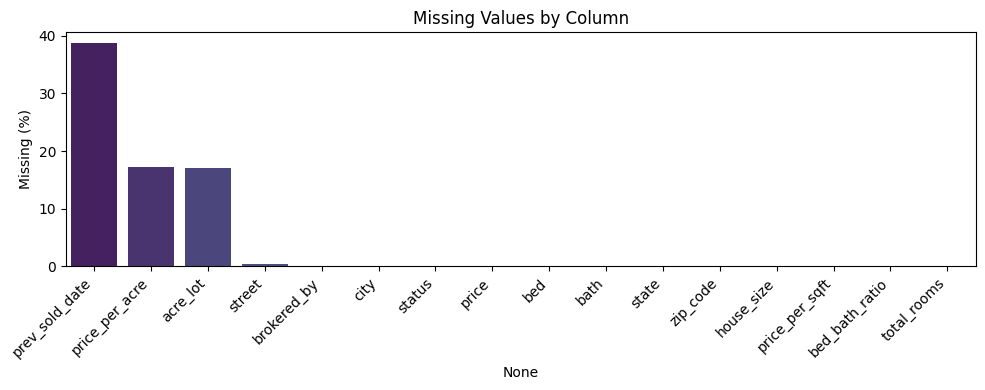

In [8]:
plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing (%)')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Distributions

In [9]:
print(f'Rows: {len(df):,}')

Rows: 856,386


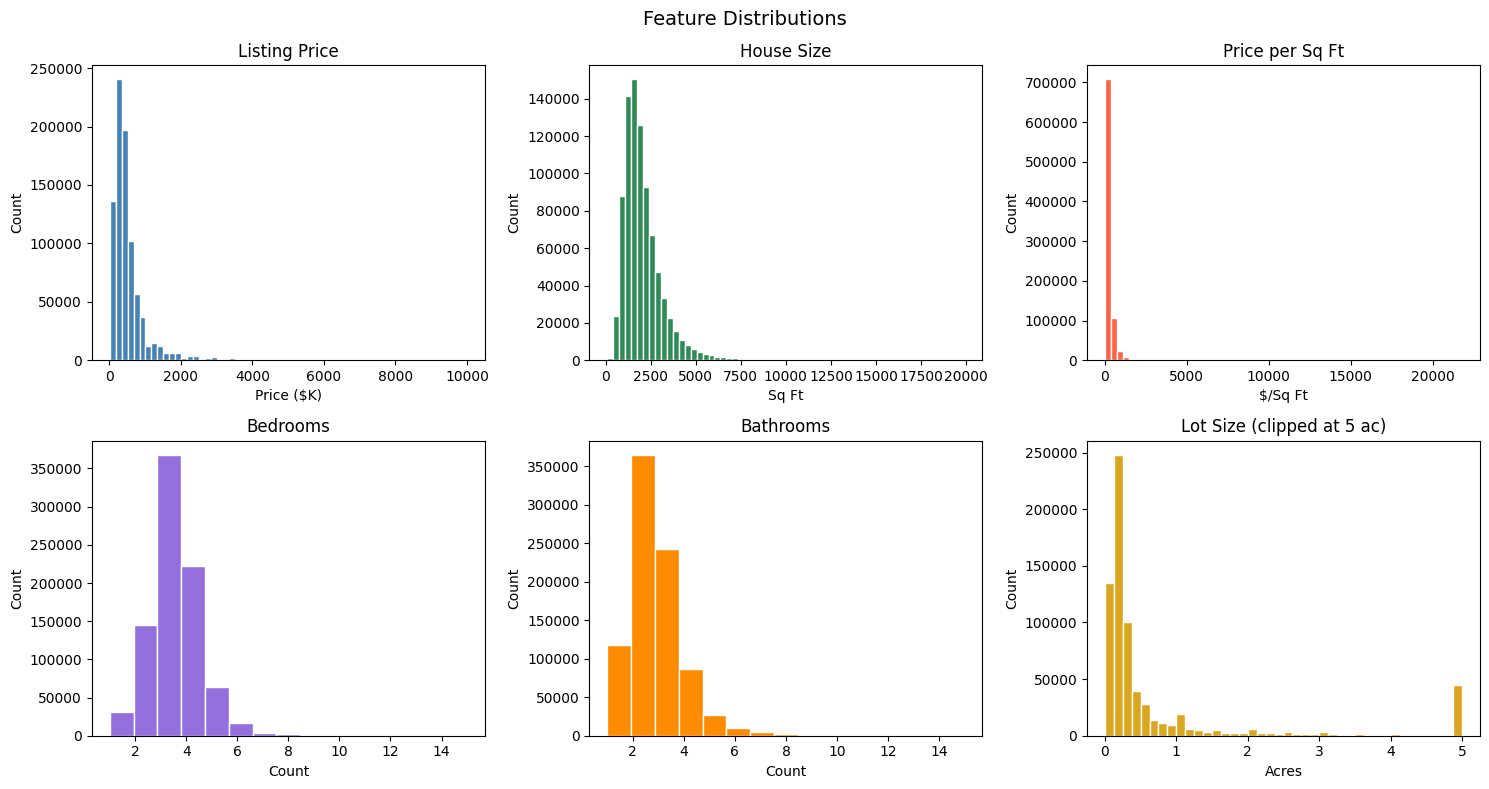

Saved → outputs/figures/01_distributions.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions', fontsize=14)

axes[0, 0].hist(df['price'] / 1_000, bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set(title='Listing Price', xlabel='Price ($K)', ylabel='Count')

axes[0, 1].hist(df['house_size'], bins=60, color='seagreen', edgecolor='white')
axes[0, 1].set(title='House Size', xlabel='Sq Ft', ylabel='Count')

axes[0, 2].hist(df['price_per_sqft'], bins=60, color='tomato', edgecolor='white')
axes[0, 2].set(title='Price per Sq Ft', xlabel='$/Sq Ft', ylabel='Count')

axes[1, 0].hist(df['bed'].dropna(), bins=15, color='mediumpurple', edgecolor='white')
axes[1, 0].set(title='Bedrooms', xlabel='Count', ylabel='Count')

axes[1, 1].hist(df['bath'].dropna(), bins=15, color='darkorange', edgecolor='white')
axes[1, 1].set(title='Bathrooms', xlabel='Count', ylabel='Count')

axes[1, 2].hist(df['acre_lot'].clip(0, 5), bins=40, color='goldenrod', edgecolor='white')
axes[1, 2].set(title='Lot Size (clipped at 5 ac)', xlabel='Acres', ylabel='Count')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/figures/01_distributions.png')

## 5. Price by State

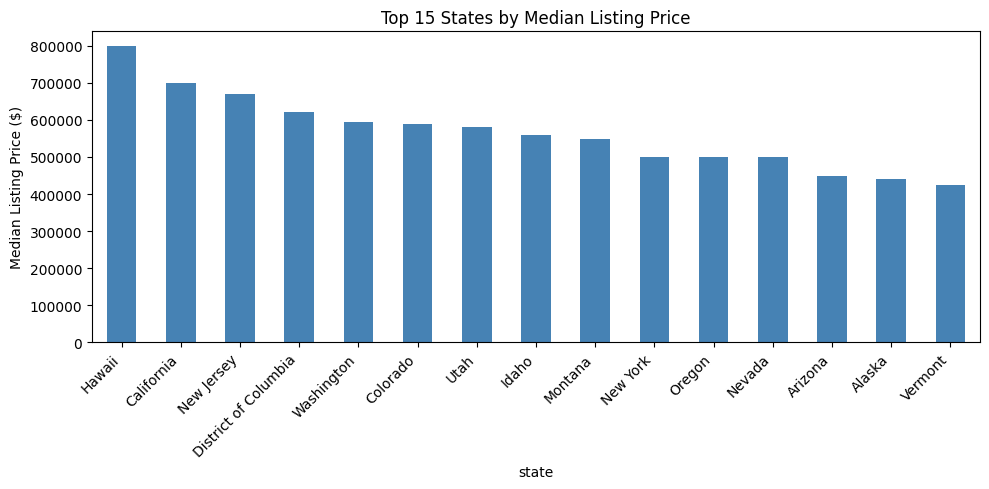

Saved → outputs/figures/01_price_by_state.png


In [11]:
top_states = (
    df.groupby('state')['price']
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 5))
top_states.plot.bar(color='steelblue')
plt.ylabel('Median Listing Price ($)')
plt.title('Top 15 States by Median Listing Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_price_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/figures/01_price_by_state.png')

## 6. ZHVI Features

Distribution of current home values and 1-year / 5-year growth rates across zip codes.

In [12]:
zhvi = pd.read_csv(ZHVI_FEATURES)
print(f'ZHVI zip codes: {len(zhvi):,}')
zhvi.describe().round(4)

ZHVI zip codes: 26,281


,zip_code,zhvi_current,zhvi_1yr_ago,growth_1yr,growth_5yr
count,26281.0000,2.628100e+04,2.628100e+04,26281.0000,25025.0000
mean,48313.9166,3.658014e+05,3.598235e+05,0.0164,0.3012
std,27395.1839,3.268955e+05,3.178474e+05,0.0514,0.1600
min,1001.0000,2.855241e+04,3.237897e+04,-0.4165,-0.5980
25%,25962.0000,1.927728e+05,1.875404e+05,-0.0103,0.2195
50%,47842.0000,2.824334e+05,2.756615e+05,0.0187,0.3204
75%,70377.0000,4.254619e+05,4.210711e+05,0.0460,0.4018
max,99929.0000,8.078219e+06,7.410641e+06,0.4180,1.1201


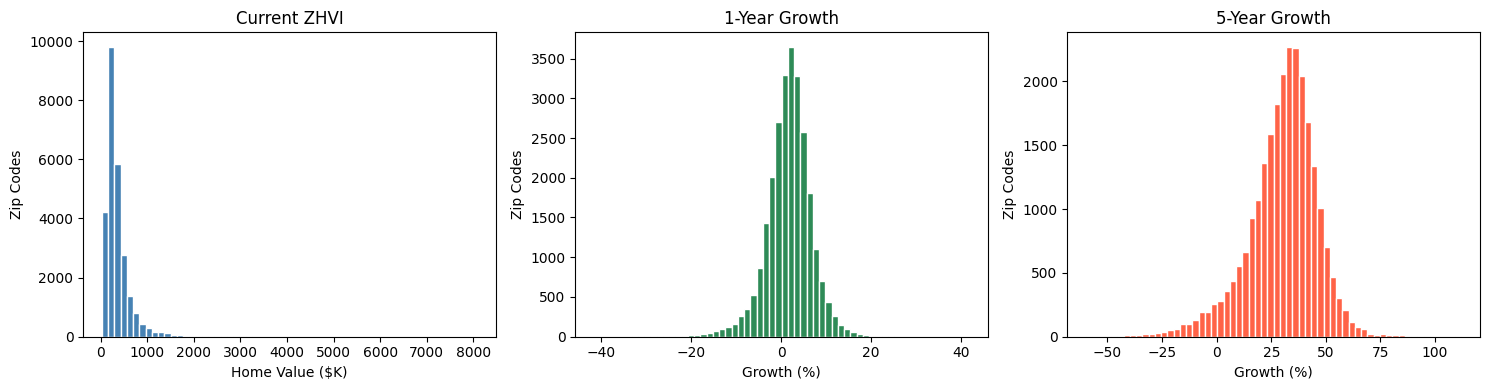

Saved → outputs/figures/01_zhvi_trend.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(zhvi['zhvi_current'].dropna() / 1_000, bins=60, color='steelblue', edgecolor='white')
axes[0].set(title='Current ZHVI', xlabel='Home Value ($K)', ylabel='Zip Codes')

axes[1].hist(zhvi['growth_1yr'].dropna() * 100, bins=60, color='seagreen', edgecolor='white')
axes[1].set(title='1-Year Growth', xlabel='Growth (%)', ylabel='Zip Codes')

axes[2].hist(zhvi['growth_5yr'].dropna() * 100, bins=60, color='tomato', edgecolor='white')
axes[2].set(title='5-Year Growth', xlabel='Growth (%)', ylabel='Zip Codes')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_zhvi_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/figures/01_zhvi_trend.png')